# 篇末综合 网络结构、传播与同步

## 学习目标与先修知识

在同一网络语义下比较结构、扩散、传播及集体节律。

先修：完成11.1—11.4；能够区分图结构、交换、传播事件（event）和相位（phase）耦合。

## 具体问题

同一张12节点联系图可以承载三种机制：对称物质交换、接触传播、节律耦合。边的数字和单位不同，能否用结构统计、守恒、重复和同步指标组成一套不混淆机制的分析？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先列出四个独立核对点：度和、交换守恒、同步事件、相位平移不变。题组中的每项独立给定输入（input），不依赖别题答案。

In [2]:
print('结构：边表/度；交换：L和总量；传播：固定抽样表；节律：R与尾窗频率。')

结构：边表/度；交换：L和总量；传播：固定抽样表；节律：R与尾窗频率。


## 模型假设

在同一组节点上分别定义交换、传播和相位模型（model）。图结构为无向简单网络；交换边附非负率且对称；传播使用独立随机表和同步更新；相位耦合归一化按节点度。每类机制各自说明单位和不确定性，不能把图形布局当成额外数据。

## 数学解释与推导

本篇的共同骨架是图 $G=(V,E)$，但作用算子不同。结构问题使用 $A$、度、路径；对称扩散为 $\dot m=-L(m/V)$ 并检查 $\mathbf1^\mathsf Tm$；传播每步把旧 I 邻居和固定随机数映射成新状态（state）；相位模型以正弦相位差耦合，并用 $R=|n^{-1}\sum e^{i\theta}|$ 与尾窗频率极差分开衡量。相同节点和边数是比较结构的起点，不等于三种动力学有相同参数（parameter）意义。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def graph_summary(n, edges):
    """Degrees, sorted connected components and all-pairs path mean (or None)."""
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    remaining = set(range(n))
    components = []
    while remaining:
        start = min(remaining)
        queue = [start]
        remaining.remove(start)
        part = []
        for v in queue:
            part.append(v)
            for w in range(n):
                if a[v][w] and w in remaining:
                    remaining.remove(w)
                    queue.append(w)
        components.append(sorted(part))
    lengths = []
    for start in range(n):
        distance = [-1] * n
        distance[start] = 0
        queue = [start]
        for v in queue:
            for w in range(n):
                if a[v][w] and distance[w] < 0:
                    distance[w] = distance[v] + 1
                    queue.append(w)
        lengths.extend(distance[w] for w in range(start + 1, n) if distance[w] >= 0)
    mean_path = sum(lengths) / len(lengths) if len(components) == 1 and lengths else None
    return degree, components, mean_path


def laplacian(n, weighted_edges):
    """Symmetric exchange operator; an edge is [i,j,rate]."""
    import numpy as np
    matrix = np.zeros((n, n), dtype=float)
    for i, j, rate in weighted_edges:
        matrix[i, i] += rate
        matrix[j, j] += rate
        matrix[i, j] -= rate
        matrix[j, i] -= rate
    return matrix.tolist()


def diffuse_amounts(n, weighted_edges, initial, volumes, dt, steps):
    """Forward Euler for dm/dt=-L(m/V); returns initial and subsequent amounts."""
    import numpy as np
    operator = np.asarray(laplacian(n, weighted_edges), dtype=float)
    volume = np.asarray(volumes, dtype=float)
    amount = np.asarray(initial, dtype=float)
    history = [amount.tolist()]
    for _ in range(steps):
        amount = amount - dt * (operator @ (amount / volume))
        history.append(amount.tolist())
    return history


def sir_fixed(n, edges, initial, beta, gamma, infection_draws, recovery_draws):
    """Synchronous S=0,I=1,R=2 updates with pre-specified uniform draws."""
    a = adjacency(n, edges)
    state = list(initial)
    history = [state.copy()]
    for edge_random, recovery_random in zip(infection_draws, recovery_draws):
        next_state = state.copy()
        for i in range(n):
            if state[i] == 0 and any(a[i][j] and state[j] == 1 and edge_random[i][j] < beta
                                     for j in range(n)):
                next_state[i] = 1
            elif state[i] == 1 and recovery_random[i] < gamma:
                next_state[i] = 2
        state = next_state
        history.append(state.copy())
    ever = sum(any(row[i] != 0 for row in history) for i in range(n))
    active_steps = sum(any(value == 1 for value in row) for row in history[:-1])
    return history, ever, active_steps


def order_parameter(phases):
    import numpy as np
    return float(abs(np.exp(1j * np.asarray(phases, dtype=float)).mean()))


def phase_step(phases, frequencies, edges, coupling, dt):
    """One explicit network phase step; coupling normalized by node degree."""
    import math
    n = len(phases)
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    return [phases[i] + dt * (frequencies[i] + coupling / max(1, degree[i]) *
                             sum(a[i][j] * math.sin(phases[j] - phases[i]) for j in range(n)))
            for i in range(n)]


def phase_run(phases, frequencies, edges, coupling, dt, steps):
    current = list(phases)
    history = [current.copy()]
    for _ in range(steps):
        current = phase_step(current, frequencies, edges, coupling, dt)
        history.append(current)
    return history, [order_parameter(row) for row in history]


def locking_spread(history, dt, tail_steps):
    """Range of per-oscillator mean frequency over the final tail window."""
    last = history[-1]
    before = history[-tail_steps - 1]
    frequencies = [(a - b) / (dt * tail_steps) for a, b in zip(last, before)]
    return max(frequencies) - min(frequencies), frequencies

## 对照实验

在同一四节点环上展示结构、扩散、一次固定传播和节律；每幅图标出与其机制相应的量，传播轨迹（trajectory）展示给定抽样表下的人数变化。

度 [2, 2, 2, 2] 全图平均路径 1.3333333333333333 传播一次曾感染 4 人


C:\Users\10149\AppData\Local\Temp\ipykernel_73112\1696899382.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


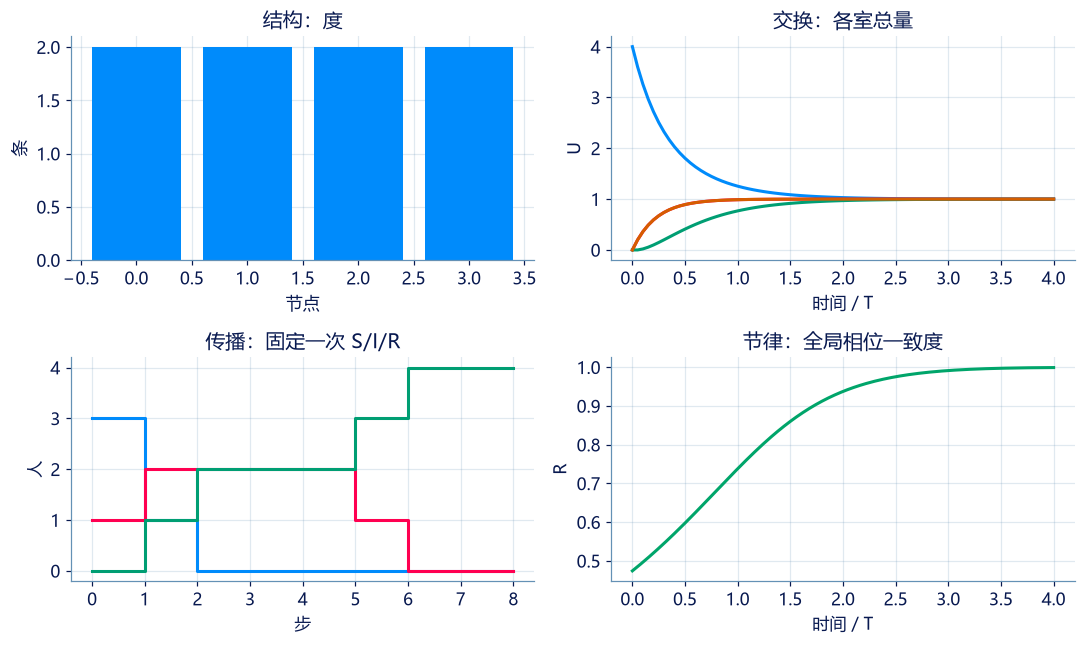

In [4]:
e=[[0,1],[1,2],[2,3],[3,0]]; degree,parts,distance=graph_summary(4,e)
amount=np.array(diffuse_amounts(4,[[i,j,1.] for i,j in e],[4.,0.,0.,0.],[1.]*4,.05,80))
rng=np.random.default_rng(1111);draw=rng.random((8,4,4)).tolist();recover=rng.random((8,4)).tolist()
sir,ever,active=sir_fixed(4,e,[1,0,0,0],.4,.3,draw,recover)
phase,order=phase_run([0.,1.,2.,3.],[1.,1.1,.9,1.],e,.8,.02,200)
print('度',degree,'全图平均路径',distance,'传播一次曾感染',ever,'人')
fig,axes=plt.subplots(2,2,figsize=(10,6))
axes[0,0].bar(range(4),degree,color=BLUE);axes[0,0].set(title='结构：度',xlabel='节点',ylabel='条')
axes[0,1].plot(np.arange(len(amount))*.05,amount);axes[0,1].set(title='交换：各室总量',xlabel='时间 / T',ylabel='U')
counts=np.array([[row.count(0),row.count(1),row.count(2)] for row in sir]);axes[1,0].step(range(len(sir)),counts)
axes[1,0].set(title='传播：固定一次 S/I/R',xlabel='步',ylabel='人')
axes[1,1].plot(np.arange(len(order))*.02,order,color=GREEN);axes[1,1].set(title='节律：全局相位一致度',xlabel='时间 / T',ylabel='R')
fig.tight_layout();plt.show()

## 结果解释

同一网络结构并不能替代机制定义。结构图给出可达性，交换总量逐步摊开且守恒，传播图仅是已给抽样表的一次结果，节律图仅是相位一致而非完整锁频诊断。

### 独立核对

四项互不依赖的核对：度和、各时刻交换总量、传播状态合法性、序参量（order parameter）共同平移不变。

In [5]:
assert sum(degree)==2*len(e)
np.testing.assert_allclose(amount.sum(axis=1),4.,atol=1e-9)
assert all(len(row)==4 and all(v in (0,1,2) for v in row) for row in sir)
np.testing.assert_allclose(order_parameter([.2,1.2]),order_parameter([.2+2,1.2+2]),atol=1e-12)
print('四种机制的独立不变量均通过。')

四种机制的独立不变量均通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：先说清连接契约

在课程人工网络中，边权可能表示接触次数或交换率。哪些陈述成立？

- **A.** 解释动态前先明确权重、方向和节点含义。
- **B.** 画面上相近的节点必须有边。
- **C.** 交换率可直接当成无量纲（dimensionless）感染概率（probability）。
- **D.** 两种机制的边权需要各自单位和规则。

[作答：先说清连接契约](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-network-contract)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：传播结构比较的预算

要比较同人数的两种网络上的传播规模，哪种安排最适合解释结构作用？

- **A.** 固定或明确匹配边/接触预算、概率（probability）规则，分层重复网络与动态抽样。
- **B.** 只让两张图颜色相同。
- **C.** 选两个最有利的随机轨迹（trajectory）。
- **D.** 一种每边概率固定，另一种每人总接触固定但不说明。

[作答：传播结构比较的预算](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-propagation-budget)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：统计综合图

对题给无向简单图返回度、分量及全图平均最短路径；不连通时平均路径为 None。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
) -> tuple[list[int], list[list[int]], float | None]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点数。 | 个 |
| `edges` | `list[list[int]]` | 无向简单边。 | 条 |

**返回值**

按以下顺序返回元组：(degrees, components, mean_path)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `degrees` | `list[int]` | 各节点度。 | 条 |
| `components` | `list[list[int]]` | 分量。 | 节点编号 |
| `mean_path` | <code>float &#124; None</code> | 连通图的不同节点对平均距离。 | 边 |

**计算规则**

同11.1.1，路径只按边数，不按布局距离。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点数。 | 3 | 个 |
| edges | 无向简单边。 | [[0, 1], [1, 2]] | 条 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 3
edges = [[0, 1], [1, 2]]

result = solve(n, edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| degrees | 各节点度。 | [1, 2, 1] | 条 |
| components | 分量。 | [[0, 1, 2]] | 节点编号 |
| mean_path | 连通图的不同节点对平均距离。 | ≈ 1.333333 | 边 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1, 2, 1],
                   [[0, 1, 2]],
                   1.3333333333333333)
```

**样例解释**

先核对度和等于两倍边数，再检查路径与连通性。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：统计综合图](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-capstone-graph)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：守恒算子与孤点

给定对称交换边，返回图拉普拉斯（graph Laplacian）；孤立节点行列为零。

**函数与代码模板**

```python
def solve(
    n: int,
    weighted_edges: list[list[float]],
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 室数。 | 个 |
| `weighted_edges` | `list[list[float]]` | 每条 [i,j,rate]。 | 容积/T |

**返回值**

直接返回 L（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `L` | `list[list[float]]` | 对称、行和为零的矩阵（matrix）。 | 容积/T |

**计算规则**

逐边增加两端对角并减去两个非对角；不凭节点图片位置加边。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 室数。 | 3 | 个 |
| weighted_edges | 每条 [i,j,rate]。 | [[0, 1, 1.0]] | 容积/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 3
weighted_edges = [[0, 1, 1.0]]

result = solve(n, weighted_edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| L | 对称、行和为零的矩阵（matrix）。 | [[1.0, -1.0, 0.0], [-1.0, 1.0, 0.0], [0.0, 0.0, 0.0]] | 容积/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1.0, -1.0, 0.0],
                   [-1.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0]]
```

**样例解释**

对每条边单独写两个室的正负收支（mass balance）。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：守恒算子与孤点](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-capstone-laplacian)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：同一随机输入下传播

同步 SIR 的旧状态（state）事件（event）和随机表已给定；返回状态轨迹（trajectory）、曾感染人数和更新前活跃步数。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
    initial: list[int],
    beta: float,
    gamma: float,
    infection_draws: list[list[list[float]]],
    recovery_draws: list[list[float]],
) -> tuple[list[list[int]], int, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 人数。 | 人 |
| `edges` | `list[list[int]]` | 无向接触边。 | 条 |
| `initial` | `list[int]` | 初始 0=S、1=I、2=R。 | 类别 |
| `beta` | `float` | 每边感染概率（probability）。 | 1 |
| `gamma` | `float` | 逐人恢复概率。 | 1 |
| `infection_draws` | `list[list[list[float]]]` | 定向边感染抽样表。 | 1 |
| `recovery_draws` | `list[list[float]]` | 恢复抽样表。 | 1 |

**返回值**

按以下顺序返回元组：(history, ever, active_steps)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[int]]` | 全部状态。 | 类别 |
| `ever` | `int` | 曾感染人数。 | 人 |
| `active_steps` | `int` | 更新前至少一人感染的步数。 | 步 |

**计算规则**

同步读取旧状态；比较使用严格小于阈值。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 人数。 | 2 | 人 |
| edges | 无向接触边。 | [[0, 1]] | 条 |
| initial | 初始 0=S、1=I、2=R。 | [1, 0] | 类别 |
| beta | 每边感染概率（probability）。 | 0.5 | 1 |
| gamma | 逐人恢复概率。 | 0.5 | 1 |
| infection_draws | 定向边感染抽样表。 | [[[1.0, 1.0], [0.3, 1.0]]] | 1 |
| recovery_draws | 恢复抽样表。 | [[0.1, 1.0]] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 2
edges = [[0, 1]]
initial = [1, 0]
beta = 0.5
gamma = 0.5
infection_draws = [[[1.0, 1.0], [0.3, 1.0]]]
recovery_draws = [[0.1, 1.0]]

result = solve(n, edges, initial, beta, gamma, infection_draws, recovery_draws)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 全部状态。 | [[1, 0], [2, 1]] | 类别 |
| ever | 曾感染人数。 | 2 | 人 |
| active_steps | 更新前至少一人感染的步数。 | 1 | 步 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1, 0], [2, 1]], 2, 1)
```

**样例解释**

感染与恢复同一步发生时，先统一读旧状态再写新状态。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同一随机输入下传播](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-capstone-spread)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：判断尾窗频率锁定

history 是未取模相位（phase）轨迹（trajectory），dt 是每步时间；用最后 tail_steps 步位移除以时长计算各节点平均频率，返回最大与最小频率的差及各频率。

**函数与代码模板**

```python
def solve(
    history: list[list[float]],
    dt: float,
    tail_steps: int,
) -> tuple[float, list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 长度至少 tail_steps+1 的相位轨迹。 | rad |
| `dt` | `float` | 步长。 | T |
| `tail_steps` | `int` | 末尾窗口步数，至少1。 | 步 |

**返回值**

按以下顺序返回元组：(spread, frequencies)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `spread` | `float` | 尾窗平均频率极差。 | rad/T |
| `frequencies` | `list[float]` | 各节点尾窗平均频率。 | rad/T |

**计算规则**

保留未取模相位；不要对起末两次取模后相减。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| history | 长度至少 tail_steps+1 的相位轨迹。 | [[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]] | rad |
| dt | 步长。 | 1 | T |
| tail_steps | 末尾窗口步数，至少1。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
history = [[0.0, 0.0], [1.0, 1.0], [2.0, 2.0]]
dt = 1.0
tail_steps = 2

result = solve(history, dt, tail_steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| spread | 尾窗平均频率极差。 | 0 | rad/T |
| frequencies | 各节点尾窗平均频率。 | [1.0, 1.0] | rad/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, [1.0, 1.0])
```

**样例解释**

首例每个节点尾窗平均频率均为1 rad/T，极差为0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：判断尾窗频率锁定](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-capstone-phase)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：改变连接后的扩散尺度

对等容积无向加权图，返回给定时刻的精确扩散状态（state）和拉普拉斯升序特征值（eigenvalue）。由完整谱判断零模态（mode）个数；若存在正特征值，其最小值只描述有交换的连通分量（connected component）中最慢的可衰减模态。全无边时没有最小正特征值，也无需额外返回此项。

**函数与代码模板**

```python
def solve(
    n: int,
    weighted_edges: list[list[float]],
    initial: list[float],
    time: float,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点数。 | 个 |
| `weighted_edges` | `list[list[float]]` | 对称交换边。 | 1/T |
| `initial` | `list[float]` | 初始状态（state），用于核对精确演化。 | U |
| `time` | `float` | 非负时间。 | T |

**返回值**

按以下顺序返回元组：(state, eigenvalues)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 精确等容积扩散状态。 | U |
| `eigenvalues` | `list[float]` | 升序谱，零值允许浮点舍入。 | 1/T |

**计算规则**

使用对称特征分解 x(t)=V exp(−Λt)Vᵀx(0)。只比较同一交换模型（model）；返回完整谱由读者辨认零模态数。

**约束与边界**

- 只计算题定有限图和数值模型；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点数。 | 2 | 个 |
| weighted_edges | 对称交换边。 | [[0, 1, 1.0]] | 1/T |
| initial | 初始状态（state），用于核对精确演化。 | [2.0, 0.0] | U |
| time | 非负时间。 | 1 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 2
weighted_edges = [[0, 1, 1.0]]
initial = [2.0, 0.0]
time = 1.0

result = solve(n, weighted_edges, initial, time)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| state | 精确等容积扩散状态。 | [1.1353352832366126, 0.8646647167633872] | U |
| eigenvalues | 升序谱，零值允许浮点舍入。 | [0.0, 2.0] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.1353352832366126, 0.8646647167633872],
                   [0.0, 2.0])
```

**样例解释**

首例特征值为0和2，平均模态不衰减；断连例存在多个零模态。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：改变连接后的扩散尺度](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-capstone-gap)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：有限网络的结构结论

同频率集合、同 K 下某张捷径图的 R 较高。哪些解释仍需谨慎？

- **A.** 需核对初相、暂态（transient）、步长、网络重复与尾窗锁频。
- **B.** 只凭一张图就能推出任意规模临界阈值。
- **C.** R 较高表示此刻相位（phase）整体较集中，仍可能有个别振子明显偏离；它不能单独证明长期频率锁定（frequency locking）。
- **D.** 布局颜色已证明机制。

[作答：有限网络的结构结论](http://127.0.0.1:8000/parts/11-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E7%B3%BB%E7%BB%9F/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p11-network-claim-limit)

**进一步阅读**

结构与实现参考 [NetworkX 官方文档](https://networkx.org/documentation/stable/)；本篇各节对人工机制的简化和实验预算分别给出。